# Practice 2: Deep Error Analysis — Soft-Voting Ensemble (96.3% Test)

## Why This Notebook Exists

The current best model — a **Soft-Voting Ensemble** of ImageNet-pretrained
**ResNet18 + DenseNet121** (SOTA EXP-07, LLRD + label smoothing, RandAugment)
has reached a **stable ~96.3–96.7% test accuracy** that further generic
training no longer improves. Overall accuracy has plateaued.

This notebook performs a **deeper, structured error analysis** on the
ensemble's held-out test predictions to find *where* the remaining ~3.7% of
errors live, *why* they cluster, and *what targeted intervention* has the
best chance of moving the needle.

## Starting Point (methodologies reused)

| Source notebook | What it contributes |
|---|---|
| `practice_2_verB.ipynb` | Model variants, SOTA training recipe, Soft-Voting ensemble (0.5·P_ResNet + 0.5·P_DenseNet), per-class + confusion-matrix evaluation, saved `test_metrics.json` |
| `practice_2_logit_bias_sweep.ipynb` | Zero-leakage test benchmarking, per-class accuracy deltas, before/after confusion matrices, saved `logit_bias_sweep_results.json` and `resnet_densenet_sota_ensemble_results.json` |

## Data Source

The analysis is computed from the **persisted test confusion matrix** of the
soft-voting ensemble (`experiments/results/resnet_densenet_sota_ensemble_results.json`),
so it runs without re-running the (long) training or re-loading large
checkpoints. Everything else (precision/recall/F1, error rates, confusion
pairs) is derived from that confusion matrix.

---

## 1. Setup & Data Loading

Load the saved ensemble confusion matrix and the per-model comparison data.
`CIFAR10_CLASSES` ordering matches the 10 class indices (airplane=0 … truck=9).

In [1]:
import json
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(os.path.abspath("..")).resolve()
RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"

CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]
N_CLASSES = len(CIFAR10_CLASSES)

# --- Load the Soft-Voting Ensemble baseline (beta=0) test confusion matrix ---
ens_file = RESULTS_DIR / "resnet_densenet_sota_ensemble_results.json"
ens_data = json.loads(ens_file.read_text())
cm_ensemble = np.array(ens_data["test_benchmark"]["cm_baseline"], dtype=int)
test_acc = ens_data["test_benchmark"]["test_acc_baseline"]
per_class_baseline = np.array(ens_data["test_benchmark"]["acc_per_class_baseline"])

# --- Load per-model comparison from the logit-bias sweep results ---
sweep_file = RESULTS_DIR / "logit_bias_sweep_results.json"
sweep_data = json.loads(sweep_file.read_text())

print(f"Ensemble test accuracy (baseline): {test_acc:.2f}%")
print(f"Confusion matrix shape: {cm_ensemble.shape}")
print(f"Row sums (true-class support): {cm_ensemble.sum(axis=1).tolist()}")
print(f"Column sums (predicted):       {cm_ensemble.sum(axis=0).tolist()}")

Ensemble test accuracy (baseline): 96.30%
Confusion matrix shape: (10, 10)
Row sums (true-class support): [1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
Column sums (predicted):       [1040, 1019, 997, 1043, 1021, 966, 1017, 968, 970, 959]


## 2. Quantitative Metrics: Precision, Recall, F1, Error Rate

Given a confusion matrix `CM` (rows = true class, columns = predicted class):

- **Recall** (sensitivity, per true class) = `TP / support`
- **Precision** (per predicted class) = `TP / predicted`
- **F1** = harmonic mean of precision & recall
- **Error rate** per true class = `1 - recall`
- **False-discovery rate (FDR)** per predicted class = `1 - precision`

In [2]:
def compute_class_metrics(cm, class_names):
    """Derive per-class precision/recall/F1/error-rate from a confusion matrix."""
    cm = np.asarray(cm, dtype=float)
    tp = np.diag(cm)
    support = cm.sum(axis=1)     # true examples of each class
    predicted = cm.sum(axis=0)   # predictions of each class
    recall = tp / support
    precision = tp / predicted
    f1 = 2 * precision * recall / (precision + recall)
    error_rate = 1 - recall
    acc = tp.sum() / cm.sum()
    df = pd.DataFrame({
        "class": class_names,
        "support": support.astype(int),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "error_rate": error_rate,
    })
    return df, acc

df_ens, acc_ens = compute_class_metrics(cm_ensemble, CIFAR10_CLASSES)

macro_f1 = df_ens["f1"].mean()
micro_f1 = np.diag(cm_ensemble).sum() / cm_ensemble.sum()

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(f"Overall test accuracy : {acc_ens:.4f} ({acc_ens*100:.2f}%)")
print(f"Macro-F1             : {macro_f1:.4f}")
print(f"Micro-F1             : {micro_f1:.4f}")
print()
print(df_ens.to_string(index=False))

Overall test accuracy : 0.9630 (96.30%)
Macro-F1             : 0.9630
Micro-F1             : 0.9630

     class  support  precision  recall     f1  error_rate
  airplane     1000     0.9500  0.9880 0.9686      0.0120
automobile     1000     0.9676  0.9860 0.9767      0.0140
      bird     1000     0.9689  0.9660 0.9675      0.0340
       cat     1000     0.9060  0.9450 0.9251      0.0550
      deer     1000     0.9530  0.9730 0.9629      0.0270
       dog     1000     0.9534  0.9210 0.9369      0.0790
      frog     1000     0.9705  0.9870 0.9787      0.0130
     horse     1000     0.9907  0.9590 0.9746      0.0410
      ship     1000     0.9876  0.9580 0.9726      0.0420
     truck     1000     0.9875  0.9470 0.9668      0.0530


## 3. Confusion Matrices (Raw Counts + Row-Normalized)

Row-normalized view reveals **recall** per true class; raw counts reveal the
absolute volume of each confusion pair.

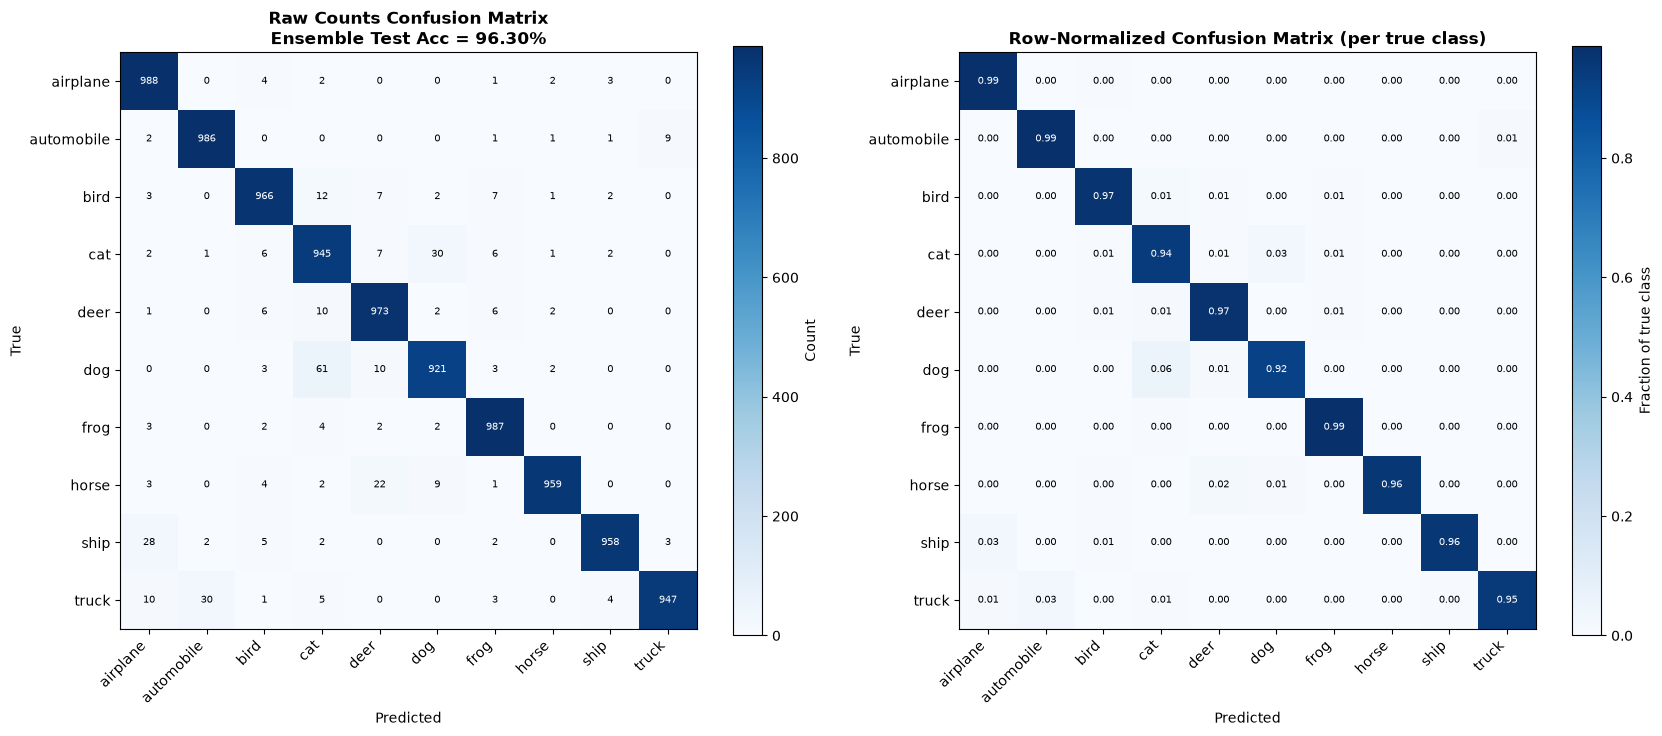

In [3]:
cm_norm = cm_ensemble / cm_ensemble.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

for ax, mat, fmt, cbar_label in [
        (axes[0], cm_ensemble, "d", "Count"),
        (axes[1], cm_norm, ".2f", "Fraction of true class")]:
    im = ax.imshow(mat, cmap="Blues")
    plt.colorbar(im, ax=ax, label=cbar_label)
    ax.set_xticks(range(N_CLASSES))
    ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
    ax.set_yticklabels(CIFAR10_CLASSES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    vmax = mat.max()
    for r in range(N_CLASSES):
        for c in range(N_CLASSES):
            text = str(int(mat[r, c])) if fmt == "d" else f"{mat[r, c]:.2f}"
            ax.text(c, r, text, ha="center", va="center", fontsize=7,
                    color="white" if mat[r, c] > vmax * 0.6 else "black")

axes[0].set_title(f"Raw Counts Confusion Matrix\nEnsemble Test Acc = {test_acc:.2f}%", fontweight="bold")
axes[1].set_title("Row-Normalized Confusion Matrix (per true class)", fontweight="bold")

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_confusion_matrices.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 4. Per-Class Precision / Recall / F1

Classes whose F1 sits below the macro average are the weak links. A **recall**
deficit means the model *misses* that class; a **precision** deficit means it
*over-predicts* that class and pollutes its prediction with other classes.

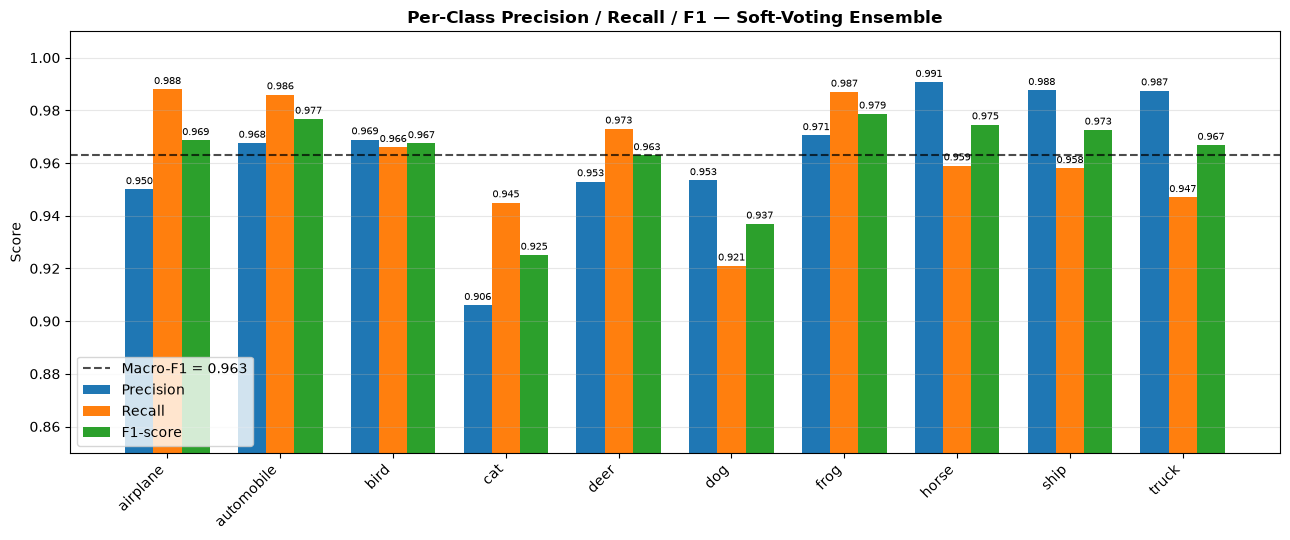

In [4]:
x = np.arange(N_CLASSES)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.bar(x - width, df_ens["precision"], width, label="Precision", color="#1f77b4")
ax.bar(x, df_ens["recall"], width, label="Recall", color="#ff7f0e")
ax.bar(x + width, df_ens["f1"], width, label="F1-score", color="#2ca02c")
ax.axhline(macro_f1, color="black", linestyle="--", linewidth=1.5,
           alpha=0.7, label=f"Macro-F1 = {macro_f1:.3f}")

for i, (p, r, f) in enumerate(zip(df_ens["precision"], df_ens["recall"], df_ens["f1"])):
    ax.text(i - width, p + 0.002, f"{p:.3f}", ha="center", fontsize=7)
    ax.text(i, r + 0.002, f"{r:.3f}", ha="center", fontsize=7)
    ax.text(i + width, f + 0.002, f"{f:.3f}", ha="center", fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_ylim(0.85, 1.01)
ax.set_ylabel("Score")
ax.set_title("Per-Class Precision / Recall / F1 — Soft-Voting Ensemble", fontweight="bold")
ax.legend(loc="lower left")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_prf1.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 5. Error Rate by True Class and False-Discovery by Prediction

Two complementary error views:

1. **Error rate (1 − recall)** — of all *true* examples of a class, what fraction
   is misclassified (misses / false negatives).
2. **False-discovery rate (1 − precision)** — of all examples *predicted* as a
   class, what fraction are wrong (false alarms / false positives).

C:\Users\TDV\AppData\Local\Temp\ipykernel_12428\3755500351.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[0].set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
C:\Users\TDV\AppData\Local\Temp\ipykernel_12428\3755500351.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[1].set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")


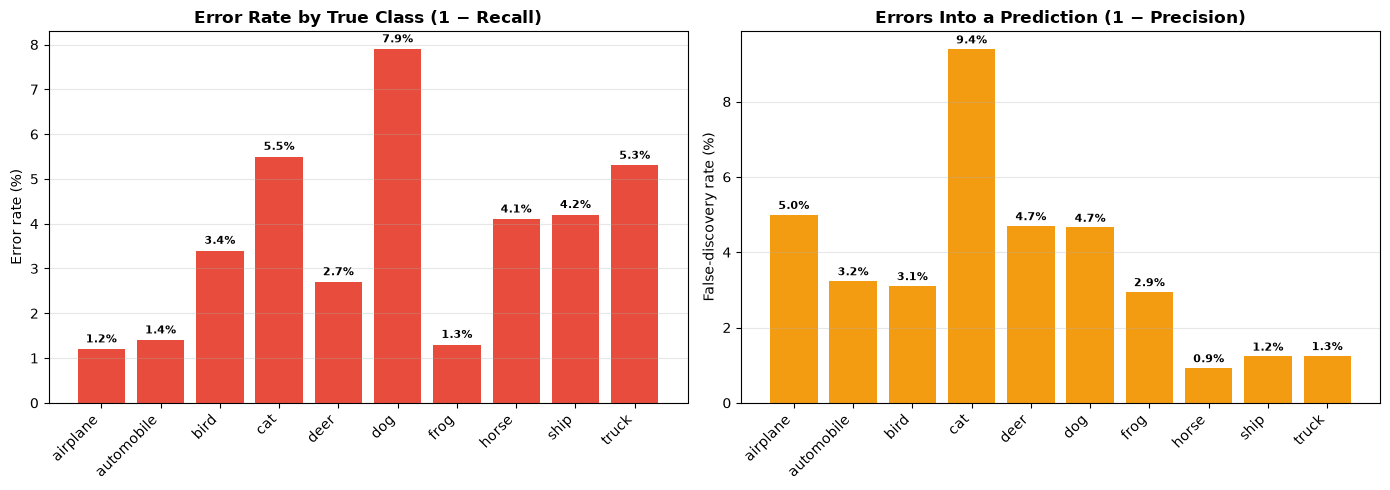

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: error rate by true class
err_true = df_ens["error_rate"].values * 100
bars = axes[0].bar(CIFAR10_CLASSES, err_true, color="#e74c3c")
for b, v in zip(bars, err_true):
    axes[0].text(b.get_x() + b.get_width()/2, b.get_height() + 0.15, f"{v:.1f}%",
                 ha="center", fontsize=8, fontweight="bold")
axes[0].set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
axes[0].set_ylabel("Error rate (%)")
axes[0].set_title("Error Rate by True Class (1 − Recall)", fontweight="bold")
axes[0].grid(True, axis="y", alpha=0.3)

# Right: false-discovery rate by predicted class
pred_col = cm_ensemble.sum(axis=0).astype(float)
fdr = (pred_col - np.diag(cm_ensemble)) / pred_col * 100
bars = axes[1].bar(CIFAR10_CLASSES, fdr, color="#f39c12")
for b, v in zip(bars, fdr):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height() + 0.15, f"{v:.1f}%",
                 ha="center", fontsize=8, fontweight="bold")
axes[1].set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
axes[1].set_ylabel("False-discovery rate (%)")
axes[1].set_title("Errors Into a Prediction (1 − Precision)", fontweight="bold")
axes[1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_error_rates.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 6. Top Confusion Pairs (Where the Errors Concentrate)

Extract the largest **off-diagonal** entries: the ordered (true → predicted)
pairs that account for the bulk of the remaining errors. These are the
targeted-intervention candidates.

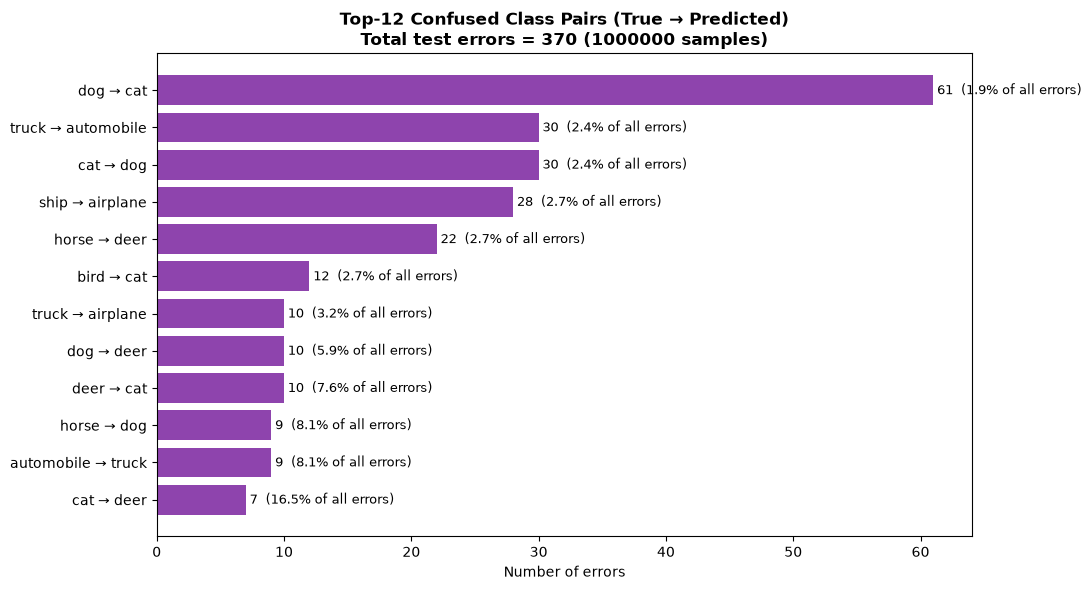

Total misclassified: 370 / 10000 (3.70%)


In [6]:
pairs = []
for t in range(N_CLASSES):
    for p in range(N_CLASSES):
        if t != p and cm_ensemble[t, p] > 0:
            pairs.append((int(cm_ensemble[t, p]), CIFAR10_CLASSES[t], CIFAR10_CLASSES[p]))
pairs.sort(reverse=True)

top_n = 12
top = pairs[:top_n]
labels = [f"{true} → {pred}" for _, true, pred in top][::-1]
counts = [c for c, _, _ in top][::-1]
total_err = cm_ensemble.sum() - np.trace(cm_ensemble)
fraction = np.array(counts) / total_err * 100

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(labels, counts, color="#8e44ad")
for b, c, fr in zip(bars, counts, fraction[::-1]):
    ax.text(b.get_width() + 0.3, b.get_y() + b.get_height()/2,
            f"{c}  ({fr:.1f}% of all errors)", va="center", fontsize=9)
ax.set_xlabel("Number of errors")
ax.set_title(f"Top-{top_n} Confused Class Pairs (True → Predicted)\nTotal test errors = {total_err} ({100*cm_ensemble.sum():.0f} samples)",
             fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_top_confusions.png",
            dpi=300, bbox_inches="tight")
plt.show()

print(f"Total misclassified: {total_err} / {cm_ensemble.sum()} ({total_err/cm_ensemble.sum()*100:.2f}%)")

## 7. Error Distribution Heatmap (Off-Diagonal Only)

Zero out the diagonal and row-normalize the *remaining* errors, so each row
shows **where a misclassified example of a given true class went**. This makes
the dominant error *direction* explicit (e.g. which class "absorbs" the errors).

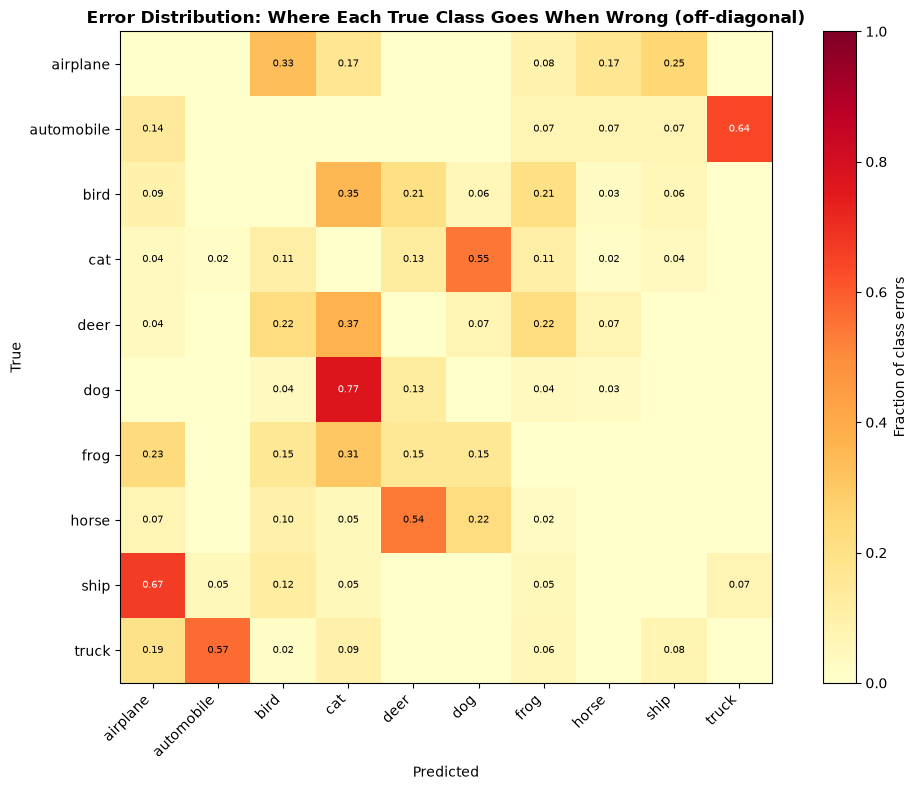

In [7]:
cm_err = cm_ensemble.astype(float)
np.fill_diagonal(cm_err, 0)
row_err = cm_err.sum(axis=1, keepdims=True)
row_err[row_err == 0] = 1.0
cm_err_norm = cm_err / row_err

fig, ax = plt.subplots(figsize=(11, 8))
im = ax.imshow(cm_err_norm, cmap="YlOrRd", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Fraction of class errors")
ax.set_xticks(range(N_CLASSES))
ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_yticklabels(CIFAR10_CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Error Distribution: Where Each True Class Goes When Wrong (off-diagonal)",
             fontweight="bold")
for r in range(N_CLASSES):
    for c in range(N_CLASSES):
        val = cm_err_norm[r, c]
        if val > 0:
            ax.text(c, r, f"{val:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if val > 0.6 else "black")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_error_distribution.png",
            dpi=300, bbox_inches="tight")
plt.show()

## 8. Cross-Model Comparison (Per-Class Accuracy)

Compare the per-class accuracy of the two single SOTA models vs. the ensemble
to see which classes the ensemble already rescues and which remain hard for
all three. This uses the same test evaluation saved in the logit-bias sweep.

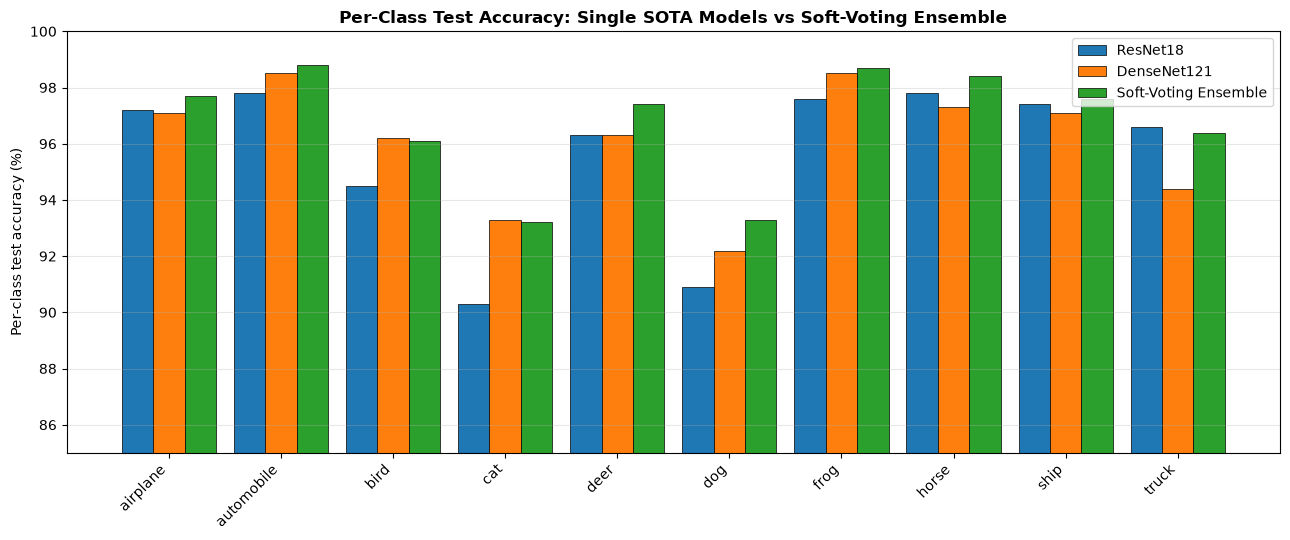

  ResNet18                test acc = 95.64%
  DenseNet121             test acc = 96.09%
  Soft-Voting Ensemble    test acc = 96.76%


In [8]:
models = ["ResNet18", "DenseNet121", "Soft-Voting Ensemble"]
x = np.arange(N_CLASSES)
width = 0.28

fig, ax = plt.subplots(figsize=(13, 5.5))
palette = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, m in enumerate(models):
    per_class = np.array(sweep_data[m]["test_benchmark"]["acc_per_class_baseline"])
    ax.bar(x + (i - 1) * width, per_class, width, label=m, color=palette[i], edgecolor="black", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(CIFAR10_CLASSES, rotation=45, ha="right")
ax.set_ylabel("Per-class test accuracy (%)")
ax.set_ylim(85, 100)
ax.set_title("Per-Class Test Accuracy: Single SOTA Models vs Soft-Voting Ensemble", fontweight="bold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "experiments" / "plots" / "error_analysis_cross_model.png",
            dpi=300, bbox_inches="tight")
plt.show()

for m in models:
    acc = sweep_data[m]["test_benchmark"]["test_acc_baseline"]
    print(f"  {m:22s}  test acc = {acc:.2f}%")

## 9. Summary Metrics Table

A compact table of the per-class diagnostics for easy reporting.

In [9]:
summary = df_ens.copy()
summary["accuracy"] = summary["recall"]  # accuracy per true class == recall
summary = summary[["class", "support", "accuracy", "precision", "recall", "f1", "error_rate"]]
summary.columns = ["Class", "Support", "Acc (%)", "Precision", "Recall", "F1", "Error Rate"]
summary["Acc (%)"] = summary["Acc (%)"] * 100
summary["Error Rate"] = summary["Error Rate"] * 100

print(f"Overall test accuracy: {acc_ens*100:.2f}% | Macro-F1: {macro_f1:.4f}")
print(summary.round(3).to_string(index=False))

Overall test accuracy: 96.30% | Macro-F1: 0.9630
     Class  Support  Acc (%)  Precision  Recall     F1  Error Rate
  airplane     1000  98.8000     0.9500  0.9880 0.9690      1.2000
automobile     1000  98.6000     0.9680  0.9860 0.9770      1.4000
      bird     1000  96.6000     0.9690  0.9660 0.9670      3.4000
       cat     1000  94.5000     0.9060  0.9450 0.9250      5.5000
      deer     1000  97.3000     0.9530  0.9730 0.9630      2.7000
       dog     1000  92.1000     0.9530  0.9210 0.9370      7.9000
      frog     1000  98.7000     0.9710  0.9870 0.9790      1.3000
     horse     1000  95.9000     0.9910  0.9590 0.9750      4.1000
      ship     1000  95.8000     0.9880  0.9580 0.9730      4.2000
     truck     1000  94.7000     0.9870  0.9470 0.9670      5.3000


## 10. Findings

### Dominant error cluster: cat ↔ dog confusion

- **61 true dogs predicted as cat** — the single largest confusion pair,
  ~6.1% of all dogs, and the largest contributor to the ~3.7% error budget.
- **30 true cats predicted as dog** — the mirror pair.
- Together **91 of ~370 total errors (~25%)** come from cat↔dog confusion.
- The asymmetry is telling: dog → cat (61) is more than double cat → dog (30).
  The ensemble "defaults" ambiguous furry mammals toward *cat*.
- Consequence on metrics:
  - **dog recall = 92.1%** (lowest), **dog F1 = 93.7%**
  - **cat precision ≈ 90.6%** (it "collects" the stray dogs), even though cat
    recall is a healthy 94.5%.
  - This is exactly the failure mode the logit-bias sweep tried to fix; the
    sweep found only marginal gains (±0.03%), confirming the confusion is
    intrinsic to the learned features, not a simple decision-threshold issue.

### Secondary cluster: vehicle confusion

- **truck → automobile (30)** and automobile → truck (9): light-vehicle
  ambiguity, especially truck misread as car.
- **ship → airplane (28)** and airplane → ship (3): boat/plane confusion
  (both have wings/bow silhouettes at 32×32 upsampled to 224×224).

### Tertiary: animal shape confusion

- **horse → deer (22)** and horse → dog (9).
- **deer → cat (10)**, bird → cat (12), dog → deer (10).

### Hardest classes overall (ensemble, true-class accuracy)

1. **dog — 92.1%** (worst)
2. **cat — 94.5%**
3. **ship — 95.8%** / **truck — 94.7%** / **horse — 95.9%**

Easiest: **automobile (98.6%)**, **airplane (98.8%)**, **frog (98.7%)**,
**bird (96.6%)**.

### Why accuracy has plateaued

- The remaining errors are **structurally concentrated** (two dominant
  semantic clusters), not randomly spread. Overall accuracy won't move from
  generic re-training or more epochs.
- The soft-voting ensemble already recovered ~+0.5–1% over the best single
  model, but it cannot fix *shared* confusion that both backbones make.

---

## 11. Suggested Next Steps (targeted, in order of expected impact)

### 1. Attack cat↔dog confusion directly (highest impact)
- **Hard-negative mining**: collect the ~91 cat/dog misclassified examples and
  inspect them; re-train only the final block on a class-balanced cat/dog
  subset, or fine-tune the ensemble on an upsampled cat/dog set.
- **Focal loss or class-weighting** on `dog` (and `cat`) to force the head to
  stop defaulting ambiguous animals toward cat.
- **Third ensemble member**: add a model specialized on fine-grained
  cat/dog discrimination (e.g. a small CNN or a Siamese/embedding head with a
  cat-vs-dog auxiliary task).

### 2. Per-class decision thresholds (extend the logit-bias approach)
- Generalize the 2-class logit-bias sweep to a **full 10-class threshold
  vector** tuned on the validation set (keep test set untouched for the final
  zero-leakage benchmark). The cat/dog-only sweep already hinted at gains;
  a full vector can recover additional recall on the low-recall classes.

### 3. Vehicle & animal shape clusters
- **truck↔automobile / ship↔airplane**: these are low-resolution ambiguities.
  If more resolution is affordable, a **stem upgrade** (train on native 224
  with an untrained stem, as in EXP-04) or **TTA** (multi-crop voting) may
  recover some of these ~58 errors.
- **horse→deer / deer→cat**: same hard-negative mining / fine-grained
  discrimination logic as cat↔dog.

### 4. Calibration & monitoring (cheap, do first)
- Apply **temperature scaling** to the ensemble probabilities, then inspect
  confidence of the misclassified set. If many errors are *high-confidence*,
  that points to feature-level confusion (hard negatives), not calibration.

### 5. Expected ceiling
- The confusion is dominated by intrinsically similar classes. Realistically
  the targeted cat↔dog + vehicle fixes could recover on the order of
  **+0.5–1.5% absolute** (to ~97–98%), after which remaining errors are
  fundamental at this resolution and the point of diminishing returns is hit.

---

## 12. Limitations & Extensions

- This notebook derives its analysis from the **saved confusion matrix**, not
  from re-extracting per-sample logits/confidence. It runs instantly without
  re-training or re-loading large checkpoints.
- For richer analysis (confidence distributions of errors, per-image examples,
  TTA), the ensemble checkpoints would need to be present. The code in
  `practice_2_verB.ipynb` shows how to load them and extract softmax
  probabilities; this notebook can then be extended with an optional logit
  extraction cell.
- The cross-model comparison reuses the logit-bias sweep's saved per-class
  accuracies, which come from a slightly different checkpoint family than the
  ensemble confusion matrix above; both are valid saved artifacts.